# Artificial Conditioning Vector Test

This notebook reuses the latest artificial dataset YAML emitted by `demo_artificial_non_streaming.ipynb` and the most recent saved artificial graph generator. It then checks whether graph-level conditioning steers generated samples toward the requested path length and node-label histogram.

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import json
import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset
from conditional_node_field_graph_generator.persistence import load_graph_generator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.2.2
CUDA available: False


In [7]:
def latest_file(root, pattern):
    matches = sorted(Path(root).glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f'No files matching {pattern!r} under {root}.')
    return matches[0]


def read_simple_yaml(path):
    config = {}
    for line_number, raw_line in enumerate(Path(path).read_text(encoding='utf-8').splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if ':' not in line:
            raise ValueError(f'Invalid config line {line_number}: {raw_line!r}')
        key, value = line.split(':', 1)
        key = key.strip()
        value = value.strip()
        if not key:
            raise ValueError(f'Invalid empty config key on line {line_number}.')
        config[key] = None if value == '' else json.loads(value)
    return config


ARTIFICIAL_DATASET_CONFIG_PATH = latest_file(REPO_ROOT / 'notebooks', 'artificial-cycle-path-star*.yaml')
ARTIFICIAL_DATASET_CONFIG = read_simple_yaml(ARTIFICIAL_DATASET_CONFIG_PATH)
LATEST_ARTIFICIAL_GENERATOR_PATH = latest_file(SAVED_GENERATOR_ROOT, 'artificial-cycle-path-star*.pkl')

DATASET_SIZE = int(ARTIFICIAL_DATASET_CONFIG['num_graphs'])
CYCLE_LENGTH = ARTIFICIAL_DATASET_CONFIG['cycle_length']
NUM_CYCLES = ARTIFICIAL_DATASET_CONFIG.get('num_cycles', 1)
PATH_LENGTH = ARTIFICIAL_DATASET_CONFIG['path_length']
NUM_RAYS = ARTIFICIAL_DATASET_CONFIG['num_rays']
RAY_LENGTH = ARTIFICIAL_DATASET_CONFIG['ray_length']
NODE_ALPHABET_SIZE = ARTIFICIAL_DATASET_CONFIG.get('node_alphabet_size', 1)
EDGE_ALPHABET_SIZE = ARTIFICIAL_DATASET_CONFIG.get('edge_alphabet_size', 1)
NODE_ALPHABET_KIND = ARTIFICIAL_DATASET_CONFIG.get('node_alphabet_kind', 'int')
EDGE_ALPHABET_KIND = ARTIFICIAL_DATASET_CONFIG.get('edge_alphabet_kind', 'int')
COMPONENT_SPECIFIC_ALPHABETS = ARTIFICIAL_DATASET_CONFIG.get('component_specific_alphabets', True)
RANDOM_SEED = ARTIFICIAL_DATASET_CONFIG.get('seed')

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

print(f'Using latest artificial dataset config: {ARTIFICIAL_DATASET_CONFIG_PATH}')
print(ARTIFICIAL_DATASET_CONFIG)
print(f'Using latest artificial graph generator: {LATEST_ARTIFICIAL_GENERATOR_PATH}')

Using latest artificial dataset config: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/notebooks/artificial-cycle-path-star-n900-c4-p2-6-r2x1-na3.yaml
{'num_graphs': 900, 'cycle_length': 4, 'num_cycles': 1, 'path_length': [2, 6], 'num_rays': 2, 'ray_length': 1, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'node_alphabet_kind': 'int', 'edge_alphabet_kind': 'int', 'component_specific_alphabets': True, 'seed': 42}
Using latest artificial graph generator: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350.pkl


Loaded 900 artificial graphs from artificial-cycle-path-star-n900-c4-p2-6-r2x1-na3.yaml.
Node count min/median/max = 8/10/12
Edge count min/median/max = 8/10/12
Metadata: {'cycle_length': 4, 'num_cycles': 1, 'path_length': 2, 'num_rays': 2, 'ray_length': 1, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


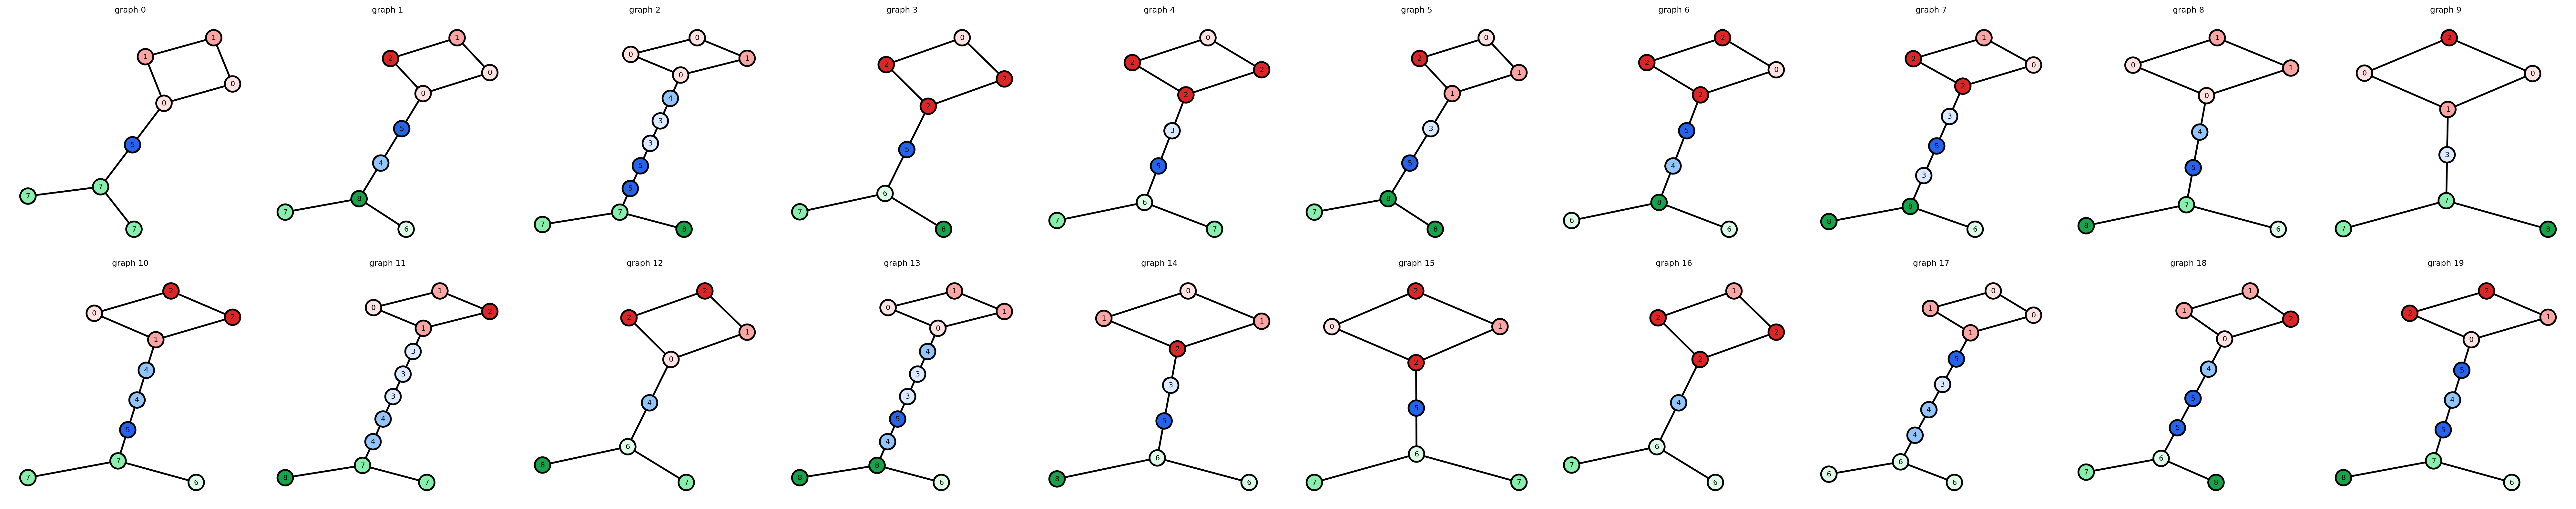

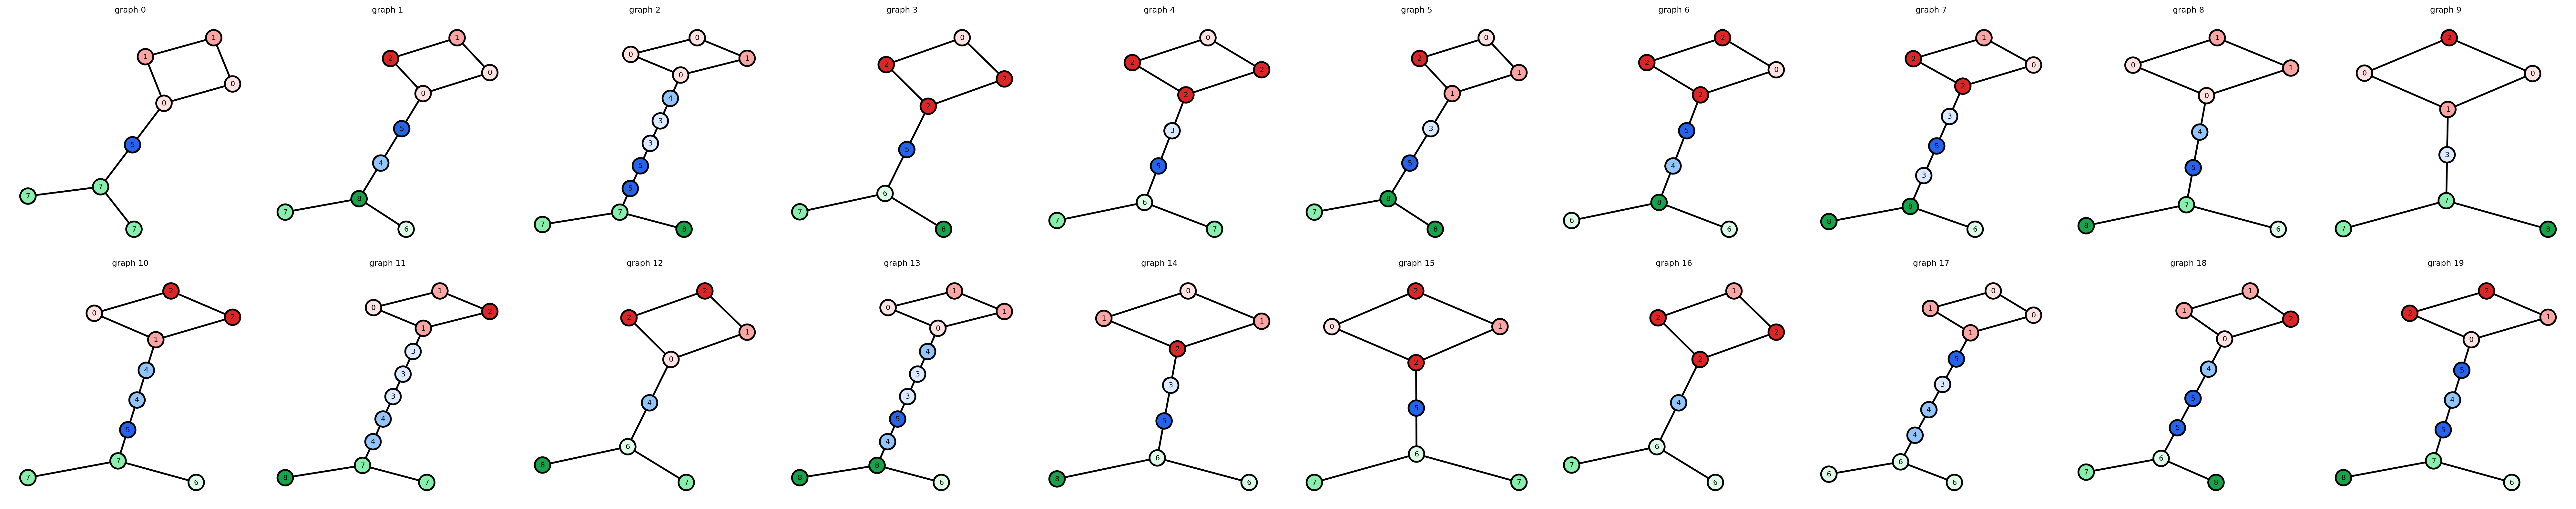

In [8]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    load_from_file=ARTIFICIAL_DATASET_CONFIG_PATH,
    save_config=False,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs from {ARTIFICIAL_DATASET_CONFIG_PATH.name}.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_artificial_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(min(20, len(graphs)))],
)

In [9]:
graph_generator = load_graph_generator(LATEST_ARTIFICIAL_GENERATOR_PATH)
print(f'Loaded graph generator: {LATEST_ARTIFICIAL_GENERATOR_PATH.name}')
print(f'Model name: {getattr(graph_generator, "model_name", None)}')
print(f'Fitted: {getattr(graph_generator, "is_fitted_", None)}')

Loaded graph generator: artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350.pkl
Loaded graph generator: artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350.pkl
Model name: artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350
Fitted: True


Process-based parallel adjacency decode exceeded 30.0s; falling back to sequential execution.


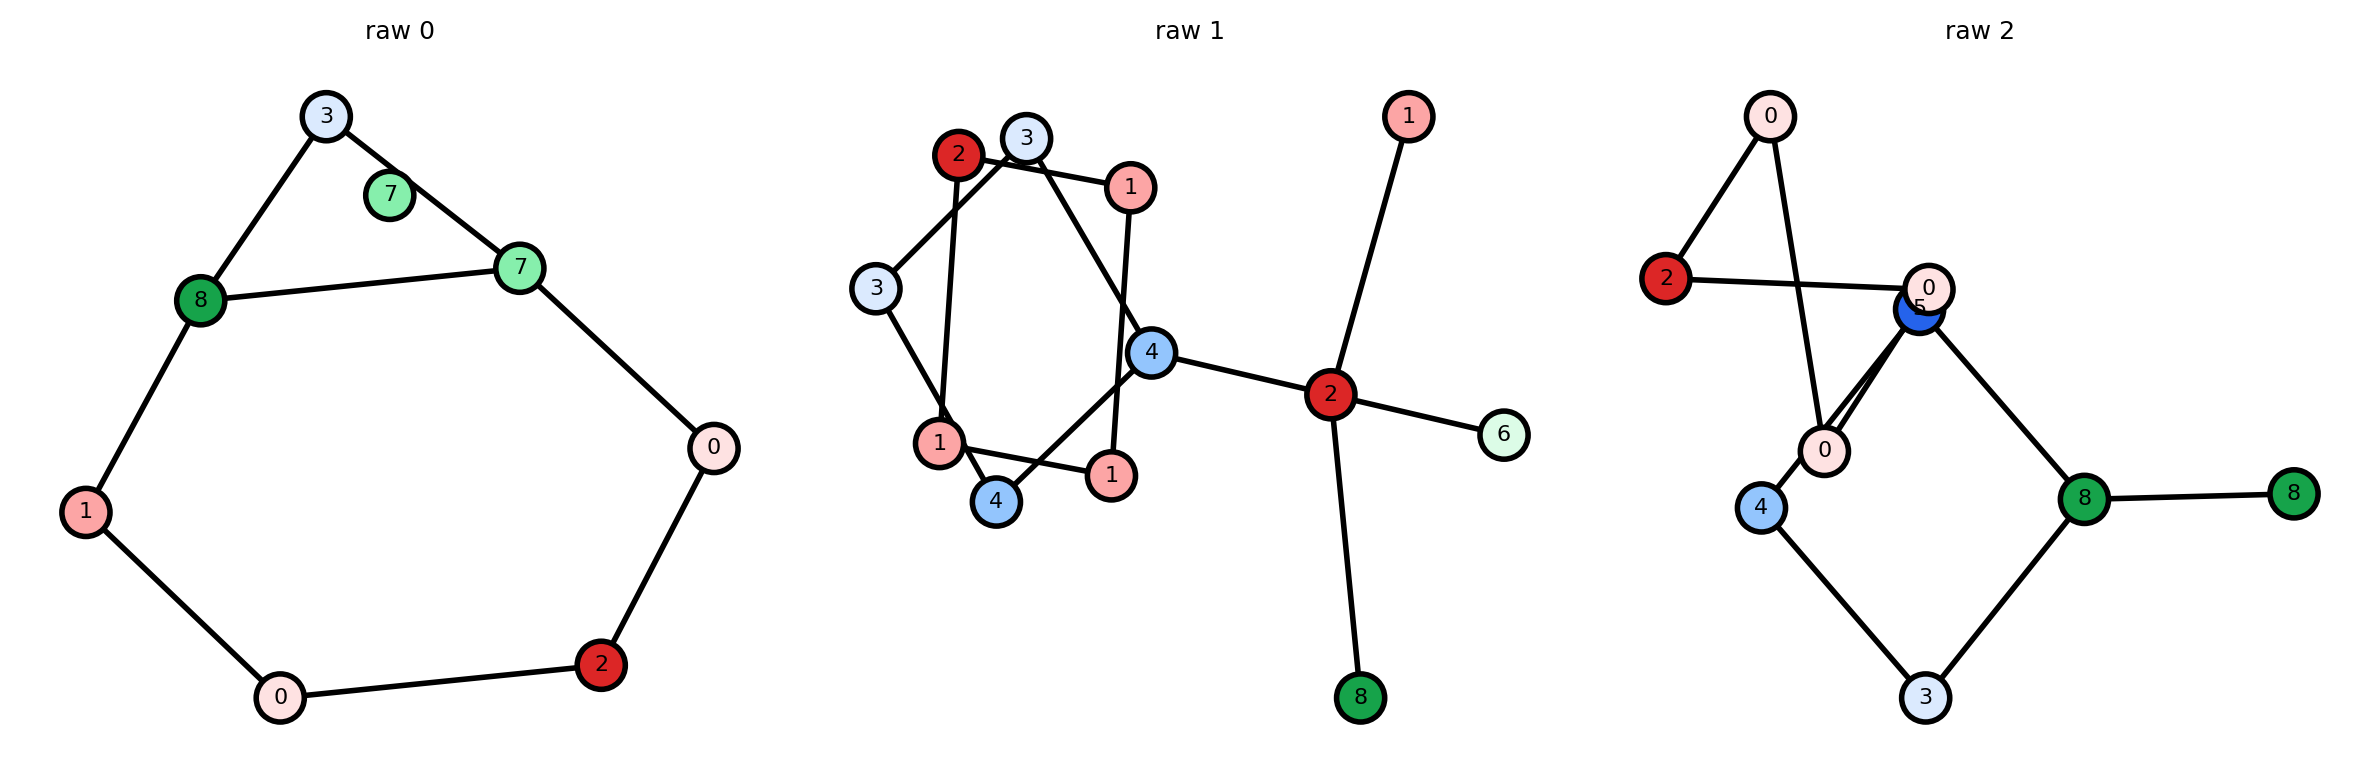

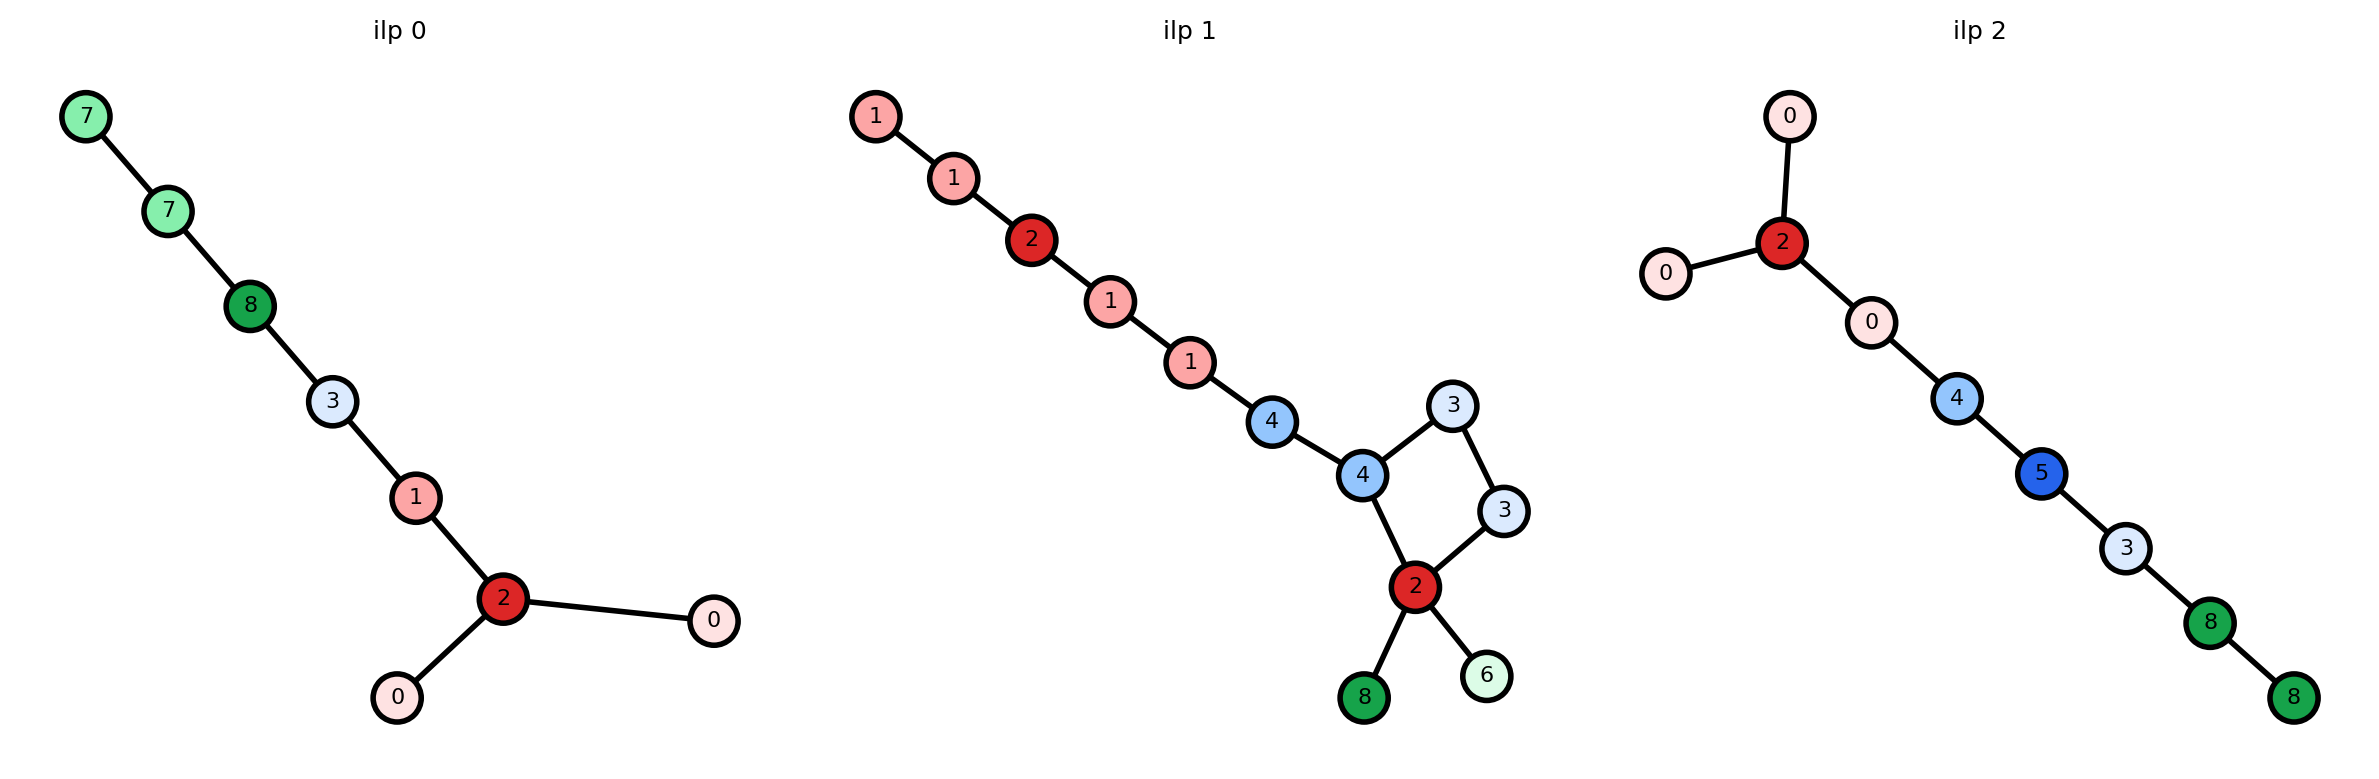

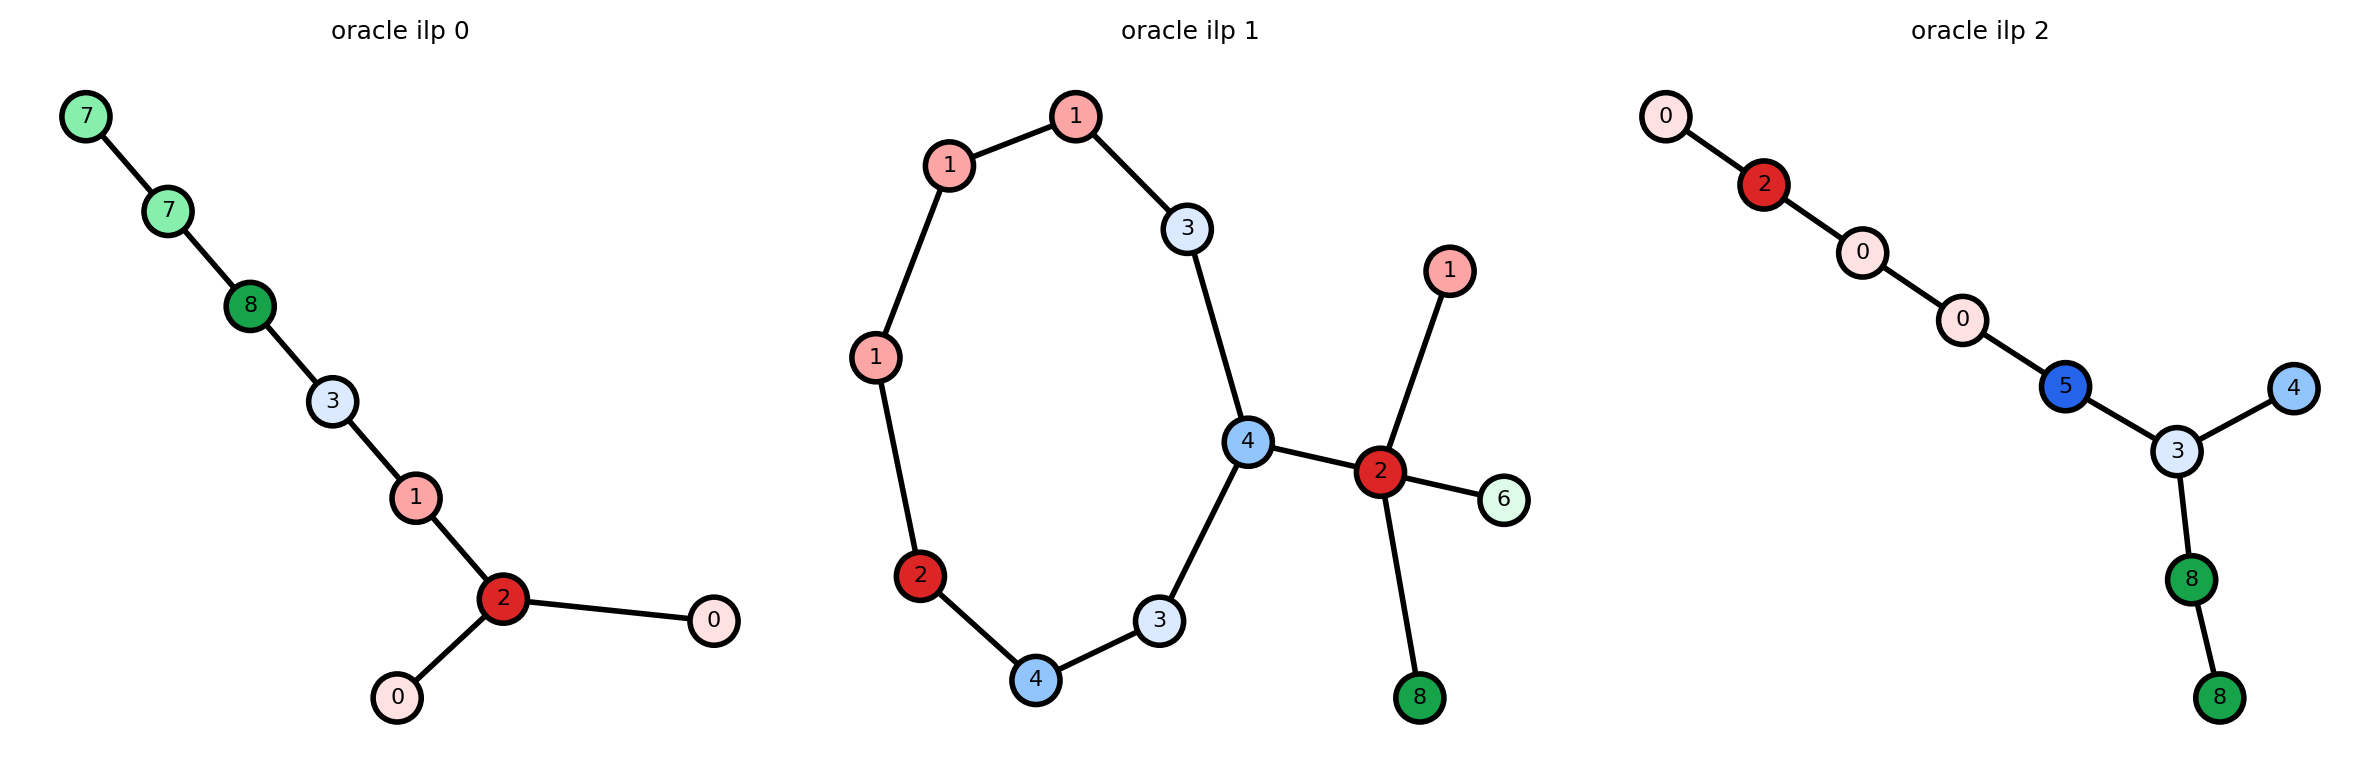

In [10]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

## Conditioning-vector steering checks

These cells sample from explicit input graphs through `graph_generator.conditional_sample(...)`, so each graph is encoded into a conditioning vector internally before decoding multiple generated graphs.

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt


def graph_path_length(graph):
    metadata = graph.graph.get('metadata', {})
    if 'path_length' in metadata:
        return int(metadata['path_length'])
    return int(sum(1 for _, attrs in graph.nodes(data=True) if attrs.get('role') == 'path'))


def node_label_counts(graph):
    return Counter(attrs.get('label') for _, attrs in graph.nodes(data=True))


def path_label_set(conditioning_graph):
    alphabets = conditioning_graph.graph.get('metadata', {}).get('node_alphabets_by_component', {})
    return set(alphabets.get('path', []))


def count_path_labeled_nodes(graph, conditioning_graph):
    labels = path_label_set(conditioning_graph)
    if not labels:
        return np.nan
    return sum(1 for _, attrs in graph.nodes(data=True) if attrs.get('label') in labels)


def estimate_path_nodes_from_total(graph, conditioning_graph):
    # In this artificial family, cycle/ray settings are fixed in this notebook and only
    # path length varies. Keep the non-path support from the conditioning graph fixed.
    desired_path_nodes = graph_path_length(conditioning_graph)
    conditioning_non_path_nodes = conditioning_graph.number_of_nodes() - desired_path_nodes
    return max(0, graph.number_of_nodes() - conditioning_non_path_nodes)


def pick_conditioning_graphs_by_path_length(graphs, path_lengths):
    selected = []
    for path_length in path_lengths:
        matches = [graph for graph in graphs if graph_path_length(graph) == path_length]
        if not matches:
            raise ValueError(f'No graph found with path_length={path_length}.')
        selected.append(matches[0])
    return selected


PATH_STEERING_SAMPLES_PER_GRAPH = 16
PATH_STEERING_VALUES = sorted({graph_path_length(graph) for graph in graphs})
path_conditioning_graphs = pick_conditioning_graphs_by_path_length(graphs, PATH_STEERING_VALUES)
path_conditioned_samples = graph_generator.conditional_sample(
    path_conditioning_graphs,
    n_samples=PATH_STEERING_SAMPLES_PER_GRAPH,
    apply_feasibility_filtering=False,
)

path_rows = []
for conditioning_graph, generated_graphs in zip(path_conditioning_graphs, path_conditioned_samples):
    desired_path_nodes = graph_path_length(conditioning_graph)
    generated_path_estimates = [
        estimate_path_nodes_from_total(generated_graph, conditioning_graph)
        for generated_graph in generated_graphs
    ]
    generated_path_label_counts = [
        count_path_labeled_nodes(generated_graph, conditioning_graph)
        for generated_graph in generated_graphs
    ]
    generated_node_counts = [generated_graph.number_of_nodes() for generated_graph in generated_graphs]
    path_rows.append({
        'conditioning_path_nodes': desired_path_nodes,
        'conditioning_total_nodes': conditioning_graph.number_of_nodes(),
        'n_generated': len(generated_graphs),
        'mean_generated_path_nodes_from_total': np.mean(generated_path_estimates) if generated_path_estimates else np.nan,
        'std_generated_path_nodes_from_total': np.std(generated_path_estimates) if generated_path_estimates else np.nan,
        'mean_generated_path_labeled_nodes': np.nanmean(generated_path_label_counts) if generated_path_label_counts else np.nan,
        'std_generated_path_labeled_nodes': np.nanstd(generated_path_label_counts) if generated_path_label_counts else np.nan,
        'mean_generated_total_nodes': np.mean(generated_node_counts) if generated_node_counts else np.nan,
        'std_generated_total_nodes': np.std(generated_node_counts) if generated_node_counts else np.nan,
    })

path_steering_df = pd.DataFrame(path_rows)
display(path_steering_df)

ax = path_steering_df.plot(
    x='conditioning_path_nodes',
    y='mean_generated_path_nodes_from_total',
    yerr='std_generated_path_nodes_from_total',
    marker='o',
    capsize=4,
    legend=False,
    figsize=(7, 4),
)
ax.plot(
    path_steering_df['conditioning_path_nodes'],
    path_steering_df['conditioning_path_nodes'],
    linestyle='--',
    color='black',
    linewidth=1,
    label='ideal',
)
ax.set_xlabel('conditioning graph path nodes')
ax.set_ylabel('generated path nodes, estimated from total support')
ax.set_title('Does conditioning steer generated path length?')
ax.legend()
plt.show()

for conditioning_graph, generated_graphs in zip(path_conditioning_graphs, path_conditioned_samples):
    examples = generated_graphs[: min(4, len(generated_graphs))]
    plot_artificial_graphs(
        [conditioning_graph, *examples],
        n_cols=1 + len(examples),
        titles=[
            f'cond path={graph_path_length(conditioning_graph)}',
            *[f'sample {idx}' for idx in range(len(examples))],
        ],
    )

In [ ]:
LABEL_HISTOGRAM_CONDITIONING_PATH = max(PATH_STEERING_VALUES)
LABEL_HISTOGRAM_SAMPLES = 32
label_conditioning_graph = pick_conditioning_graphs_by_path_length(
    graphs,
    [LABEL_HISTOGRAM_CONDITIONING_PATH],
)[0]
label_samples = graph_generator.conditional_sample(
    [label_conditioning_graph],
    n_samples=LABEL_HISTOGRAM_SAMPLES,
    apply_feasibility_filtering=False,
)[0]

if not label_samples:
    raise RuntimeError('No graphs were generated for the selected conditioning graph.')

conditioning_counts = node_label_counts(label_conditioning_graph)
all_labels = sorted(
    set(conditioning_counts).union(
        label
        for generated_graph in label_samples
        for label in node_label_counts(generated_graph)
    ),
    key=lambda value: str(value),
)

generated_count_rows = []
for generated_graph in label_samples:
    counts = node_label_counts(generated_graph)
    generated_count_rows.append([counts.get(label, 0) for label in all_labels])

generated_label_count_mtx = np.asarray(generated_count_rows, dtype=float)
label_histogram_df = pd.DataFrame({
    'label': all_labels,
    'conditioning_count': [conditioning_counts.get(label, 0) for label in all_labels],
    'mean_generated_count': generated_label_count_mtx.mean(axis=0),
    'std_generated_count': generated_label_count_mtx.std(axis=0),
})
label_histogram_df['mean_abs_error'] = (
    label_histogram_df['mean_generated_count'] - label_histogram_df['conditioning_count']
).abs()
display(label_histogram_df)
print(f"Mean absolute label-count error: {label_histogram_df['mean_abs_error'].mean():.3f}")

x = np.arange(len(all_labels))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    x - width / 2,
    label_histogram_df['conditioning_count'],
    width,
    label='conditioning',
)
ax.bar(
    x + width / 2,
    label_histogram_df['mean_generated_count'],
    width,
    yerr=label_histogram_df['std_generated_count'],
    capsize=3,
    label='generated mean',
)
ax.set_xticks(x)
ax.set_xticklabels([str(label) for label in all_labels])
ax.set_xlabel('node label')
ax.set_ylabel('node count')
ax.set_title(
    f'Node-label histogram preservation for conditioning path={LABEL_HISTOGRAM_CONDITIONING_PATH}'
)
ax.legend()
fig.tight_layout()
plt.show()

plot_artificial_graphs(
    [label_conditioning_graph, *label_samples[:6]],
    n_cols=7,
    titles=['conditioning', *[f'sample {idx}' for idx in range(min(6, len(label_samples)))]],
)